# pop-comos: Generating a mock galaxy catalog

This notebook will demonstrate how to use the `pop_cosmos` package to generate a COSMOS-like mock galaxy catalog.

We'll start by importing some dependencies, and the relevant submodules from `pop_cosmos`. Before you run this notebook, you should follow the installation instructions in the `README.md`

In [1]:
#Import dependencies and pop_cosmos
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle

from astropy.cosmology import Planck18

from pop_cosmos.constants import COSMOS_FILTERS_LATEX
from pop_cosmos.catalogue import CatalogueGenerator
from pop_cosmos.emlines import EmLineEmulator
from pop_cosmos.utils import compute_derived_quantities, compute_mass_remaining

## Load the trained model(s)

In the next cell we will load a pickled `pop_cosmos.catalogue.CatalogueGenerator` object that contains the Thorp et al. (2025) version of the `pop-cosmos` model.

In [2]:
#Load model trained in Thorp et al. (2025) on the CPU
catalogue_generator = torch.load("./trained_models/catalogueModelT25.pt", weights_only=False)

And now, we will load in an additional emulator that is needed to correct the stellar masses predicted by the model (which by default are the stellar mass _formed_ by a galaxy over its lifetime) for mass loss (so we will end up with stellar mass _remaining_).

In [3]:
#Load a secondary emulator needed for some derived quantities
mass_remaining_emulator = torch.load("./trained_models/stellar_mass_emulator.pt", map_location="cpu", weights_only=False)
mass_theta_shift, mass_theta_scale = pickle.load(open("./trained_models/stellar_mass_parameter_shift-scale.pkl", "rb"))
mass_theta_shift = torch.from_numpy(mass_theta_shift)
mass_theta_scale = torch.from_numpy(mass_theta_scale)

## Generating base samples

The different parts of the `CatalogueGenerator` transform a set of base draws that are sampled from some simple distributions. The `generate_base_samples` method will give us these. We'll call it below to generate 10000 draws from the base densities.

In [4]:
#Set seeds for reproducibility
np.random.seed(7)
torch.manual_seed(7)

#Generate base samples for the diffusion model
base_noise, base_sigma, base_phi = catalogue_generator.generate_base_samples(10000)


## Generating a mock

Now, we can push the base samples through the full generative model, to produce the following quantities:
 * `noisy_fluxes`: 26-band COSMOS-like fluxes in maggies
 * `noisy_magnitudes`: 26-band logarithmic AB magnitudes
 * `noisy_asinh_magnitudes`: 26-band asinh magnitudes
 * `flux_sigmas`: Flux uncertainties in maggies
 * `theta_samples`: 16 SPS parameters
 * `model_fluxes`: Noiseless "true" fluxes in maggies
 
Our basic parameter list in `theta_samples` will contain the following:
$$
    [N, 
    \log_{10}(Z/Z_\odot), 
    \Delta\log_{10}(\text{SFR})_2, 
    \Delta\log_{10}(\text{SFR})_3, 
    \Delta\log_{10}(\text{SFR})_4,
    \Delta\log_{10}(\text{SFR})_5,
    \Delta\log_{10}(\text{SFR})_6,
    \Delta\log_{10}(\text{SFR})_7,
    \tau_2,
    n,
    \tau_1/\tau_2,
    \ln(f_\text{AGN}),
    \ln(\tau_\text{AGN}),
    \log_{10}(Z_\text{gas}/Z_\odot),
    \log_{10}(U_\text{gas}),
    z]
$$
You can find definitions of these in Table 2 of Thorp et al. (2025). The only unfamiliar one is the first parameter, defined as $N=\mu-2.5\log_{10}(M/M_\odot)$, where $\mu$ is the distance modulus.

In [5]:
#Generate a representative catalogue from the model
noisy_fluxes, noisy_magnitudes, noisy_asinh_magnitudes, flux_sigmas, theta_samples, model_fluxes = catalogue_generator(base_noise, base_sigma, base_phi)

## Process the catalog

Here, we will apply a few operations to the mock catalog. This will compute an IRAC $\textit{Ch.1}<26$ selection for the model galaxies, and will compute some derived quantities that will be useful. We'll pass `return_bins=True` to the derived quantities function, to compute the fraction of mass formed and average SFR per bin of each galaxy's star formation history (as was done in Deger et al. 2025). 

In [6]:
#Set the magnitude limit to 26 in IRAC Ch.1
lims = torch.inf*torch.ones(26)
lims[-2] = 26.0

#Generate a boolean tensor with information on which galaxies are selected
selection = catalogue_generator.selection_cut(noisy_fluxes, noisy_magnitudes, flux_sigmas, lims).detach().numpy()

#Compute some derived quantities that we might want
log10M_formed, mw_age, log10SFR, log10sSFR, M_frac_bins, log10SFR_bins, t_edge_bins = compute_derived_quantities(theta_samples, return_bins=True)
log10M_remain, log10sSFR, M_frac_remain = compute_mass_remaining(log10M_formed, log10sSFR, theta_samples, mass_theta_shift, mass_theta_scale, mass_remaining_emulator)

#Move to numpy
noisy_magnitudes = noisy_magnitudes.detach().numpy()
noisy_fluxes = noisy_fluxes.detach().numpy()
flux_sigmas = flux_sigmas.detach().numpy()
theta_samples = theta_samples.detach().numpy()
log10M_samples = log10M_remain.detach().numpy()
log10SFR_samples = log10SFR.detach().numpy()
log10sSFR_samples = log10sSFR.detach().numpy()

# SFH-related quantities
t_edge_samples = t_edge_bins.detach().numpy()
M_frac_samples = M_frac_bins.detach().numpy()
log10SFH_samples = log10SFR_bins.detach().numpy()

## Apply the selection cut

Here we'll apply the selection cut to some of the arrays we'll be using in the next steps of the notebook.

In [7]:
#Make the selection cut
noisy_magnitudes_selected = noisy_magnitudes[selection]
noisy_flux_sigmas_selected = flux_sigmas[selection]
thetas_selected = theta_samples[selection]
log10M_selected = log10M_samples[selection]
log10SFR_selected = log10SFR_samples[selection]
log10sSFR_selected = log10sSFR_samples[selection]
t_edge_selected = t_edge_samples[selection]
M_frac_selected = M_frac_samples[selection]
log10SFH_selected = log10SFH_samples[selection]

#### TEMP MY OWN WORK:
Pop cosmos catalog loaded above into memory, 
log10m_selected - stellar mass remaining
log10SFR_selected - start formation rate.

Lets plot Stellar mass vs star-formation rate


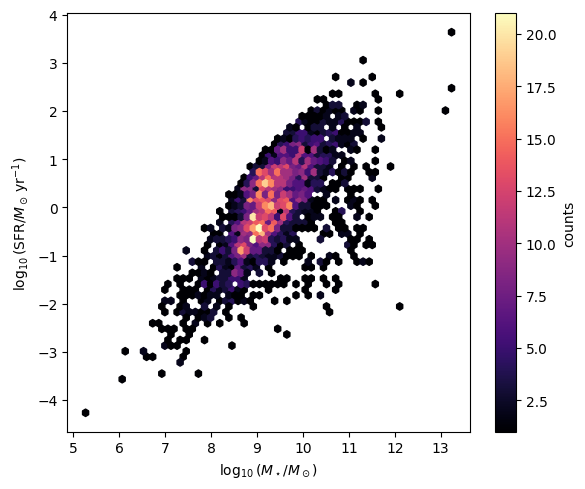

In [8]:
import matplotlib.pyplot as plt

# Stellar mass vs SFR (star-forming main sequence style plot)
plt.figure(figsize=(6, 5))
hb = plt.hexbin(log10M_selected, log10SFR_selected, gridsize=60, cmap="magma", mincnt=1)
plt.colorbar(hb, label="counts")
plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$")
plt.tight_layout()
plt.show()

Plot seems to be accurate, main seq star forming rate. Positive correlation.
Lets try color coding the main seq stars by red shift, can see how the main seq evolves with redshift

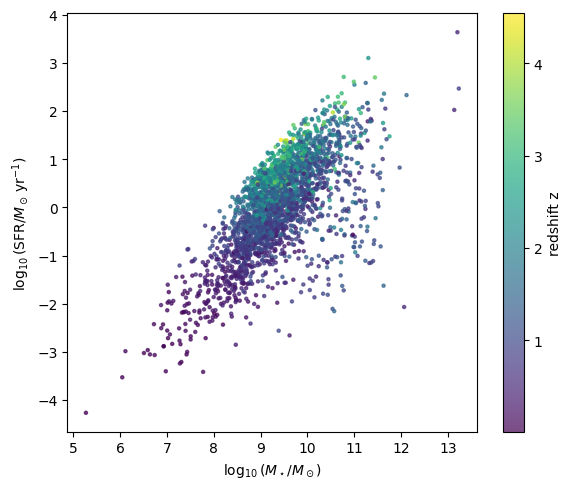

In [9]:
import matplotlib.pyplot as plt

z_selected = thetas_selected[:, -1]

plt.figure(figsize=(6, 5))
sc = plt.scatter(log10M_selected, log10SFR_selected,
                 c=z_selected, s=5, cmap="viridis", alpha=0.7)
cbar = plt.colorbar(sc)
cbar.set_label("redshift z")
plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$")
plt.tight_layout()
plt.show()

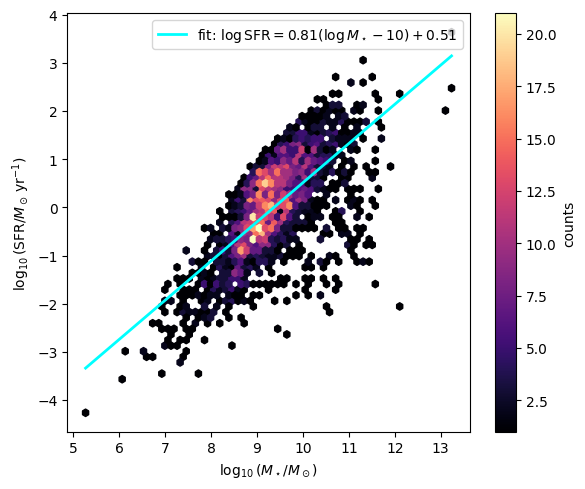

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Hexbin background
plt.figure(figsize=(6, 5))
hb = plt.hexbin(log10M_selected, log10SFR_selected,
                gridsize=60, cmap="magma", mincnt=1)
plt.colorbar(hb, label="counts")

# Straight-line fit: log SFR = a (logM - 10) + b
x = log10M_selected
y = log10SFR_selected
mask = np.isfinite(x) & np.isfinite(y)
a, b = np.polyfit(x[mask] - 10.0, y[mask], 1)

x_plot = np.linspace(x.min(), x.max(), 100)
y_plot = a * (x_plot - 10.0) + b
plt.plot(x_plot, y_plot, color="cyan", lw=2,
         label=fr"fit: $\log\mathrm{{SFR}} = {a:.2f}(\log M_\star-10)+{b:.2f}$")
plt.legend()

plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$")
plt.tight_layout()
plt.show()

As I understand:
Each point is one mock galaxy from our pop-cosmos catalog
x axis - log10 of the stellar mass remaining in solar masses.
y axis - log10 of star formation rate
so diagonal band is the SF main seq, more massive galaxies tend to have higher SFR.

when redshift added we see that higher z galaxies (distant, older) tend to have higher SFR. 

### Task 1 - Quantitative comparison with Speagle et al. (2014)

We compare pop-cosmos `log10SFR_selected` to the Speagle+2014 main-sequence relation:

$$
\log_{10}\mathrm{SFR}(M_*, t)= (0.84-0.026t)\log_{10}M_* - (6.51-0.11t)
$$

with $t$ in Gyr. To compare main-sequence galaxies, we restrict to finite values, `log10sSFR_selected > -11`, and `8.5 <= log10M_selected <= 11.5`.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18

z_selected = thetas_selected[:, -1]

def speagle_log10sfr(log10M, z):
    t_gyr = Planck18.age(np.asarray(z)).value
    return (0.84 - 0.026 * t_gyr) * np.asarray(log10M) - (6.51 - 0.11 * t_gyr)

def robust_sigma(x):
    x = np.asarray(x)
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))

finite_mask = (
    np.isfinite(log10M_selected)
    & np.isfinite(log10SFR_selected)
    & np.isfinite(log10sSFR_selected)
    & np.isfinite(z_selected)
)

sf_ms_mask = (
    finite_mask
    & (z_selected >= 0.0)
    & (z_selected < 4.0)
    & (log10M_selected >= 8.5)
    & (log10M_selected <= 11.5)
    & (log10sSFR_selected > -11.0)
)

log10SFR_speagle = speagle_log10sfr(log10M_selected, z_selected)
delta_ms = log10SFR_selected - log10SFR_speagle

overall = delta_ms[sf_ms_mask]
print(f"Task 1 overall SF sample size: {overall.size}")
print(f"Median Delta_MS = {np.nanmedian(overall):+.3f} dex")
print(f"Robust scatter (NMAD*1.4826) = {robust_sigma(overall):.3f} dex")
print(
    "Half-width (16-84 percentile) = "
    f"{0.5 * (np.nanpercentile(overall, 84) - np.nanpercentile(overall, 16)):.3f} dex"
)


Task 1 overall SF sample size: 2155
Median Delta_MS = -0.531 dex
Robust scatter (NMAD*1.4826) = 0.460 dex
Half-width (16-84 percentile) = 0.439 dex


In [12]:
z_edges = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0])
rows = []

for z_lo, z_hi in zip(z_edges[:-1], z_edges[1:]):
    m = sf_ms_mask & (z_selected >= z_lo) & (z_selected < z_hi)
    if np.sum(m) < 30:
        continue

    x = log10M_selected[m]
    y = log10SFR_selected[m]
    d = delta_ms[m]

    a_fit, c_fit = np.polyfit(x, y, 1)
    z_med = float(np.median(z_selected[m]))
    t_med = Planck18.age(z_med).value

    a_speagle = 0.84 - 0.026 * t_med
    c_speagle = -(6.51 - 0.11 * t_med)

    rows.append(
        {
            "z_bin": f"[{z_lo:.1f}, {z_hi:.1f})",
            "N": int(np.sum(m)),
            "delta_med": float(np.nanmedian(d)),
            "delta_sig": float(robust_sigma(d)),
            "slope_fit": float(a_fit),
            "slope_speagle": float(a_speagle),
            "logSFR_M10_fit": float(a_fit * 10.0 + c_fit),
            "logSFR_M10_speagle": float(a_speagle * 10.0 + c_speagle),
        }
    )

print("Per-redshift-bin comparison (SF sample):")
print(
    "z_bin       N    med_Delta   sig_Delta   slope_fit   slope_Speagle   "
    "logSFR(M=10)_fit   logSFR(M=10)_Speagle"
)
for r in rows:
    print(
        f"{r['z_bin']:<10} {r['N']:>4d}   {r['delta_med']:+.3f}      {r['delta_sig']:.3f}      "
        f"{r['slope_fit']:.3f}       {r['slope_speagle']:.3f}           "
        f"{r['logSFR_M10_fit']:+.3f}              {r['logSFR_M10_speagle']:+.3f}"
    )


Per-redshift-bin comparison (SF sample):
z_bin       N    med_Delta   sig_Delta   slope_fit   slope_Speagle   logSFR(M=10)_fit   logSFR(M=10)_Speagle
[0.0, 0.5)  127   -0.682      0.514      1.018       0.596           +0.095              +0.480
[0.5, 1.0)  547   -0.737      0.384      0.838       0.664           +0.243              +0.876
[1.0, 2.0) 1023   -0.531      0.435      0.775       0.721           +0.668              +1.203
[2.0, 3.0)  375   -0.283      0.300      0.720       0.769           +1.114              +1.481
[3.0, 4.0)   83   -0.194      0.322      0.821       0.789           +1.355              +1.597


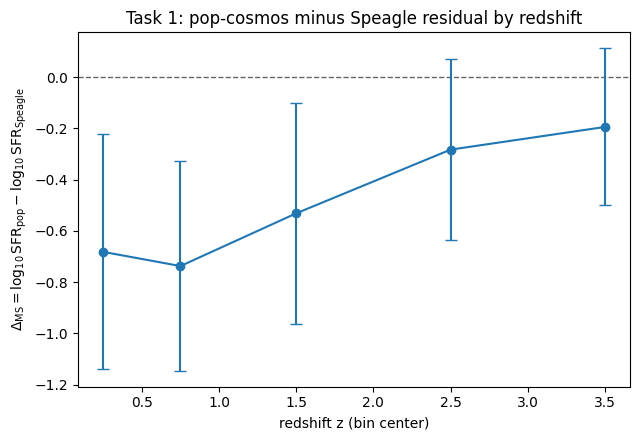

In [13]:
# Residual trend versus redshift bin
z_mid = []
delta_med = []
delta_hw = []

for z_lo, z_hi in zip(z_edges[:-1], z_edges[1:]):
    m = sf_ms_mask & (z_selected >= z_lo) & (z_selected < z_hi)
    if np.sum(m) < 30:
        continue
    d = delta_ms[m]
    z_mid.append(0.5 * (z_lo + z_hi))
    delta_med.append(np.nanmedian(d))
    delta_hw.append(0.5 * (np.nanpercentile(d, 84) - np.nanpercentile(d, 16)))

plt.figure(figsize=(6.5, 4.5))
plt.axhline(0.0, color='k', lw=1, ls='--', alpha=0.6)
plt.errorbar(z_mid, delta_med, yerr=delta_hw, fmt='o-', capsize=4)
plt.xlabel('redshift z (bin center)')
plt.ylabel(r'$\Delta_{\mathrm{MS}} = \log_{10}\mathrm{SFR}_{\mathrm{pop}} - \log_{10}\mathrm{SFR}_{\mathrm{Speagle}}$')
plt.title('Task 1: pop-cosmos minus Speagle residual by redshift')
plt.tight_layout()
plt.show()


#### Task 1 visual overlay (easy plot comparison)

Same `log10(SFR)` vs `log10(M*)` plane, but now overplotting the Speagle MS line at the median redshift of the selected bin (`1 <= z < 2`).
This gives a direct visual comparison with the earlier MS plot.


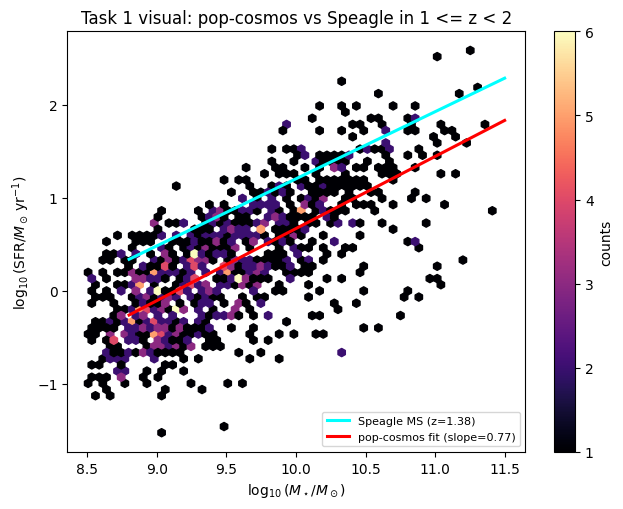

In [19]:
# Visual comparison plot: pop-cosmos density vs Speagle MS in the same plane
z_vis_lo, z_vis_hi = 1.0, 2.0
vis_mask = sf_ms_mask & (z_selected >= z_vis_lo) & (z_selected < z_vis_hi)

x_vis = log10M_selected[vis_mask]
y_vis = log10SFR_selected[vis_mask]
z_vis = z_selected[vis_mask]

z_med_vis = float(np.nanmedian(z_vis)) if np.any(vis_mask) else 1.5
x_grid = np.linspace(8.8, 11.5, 250)
y_speagle_vis = speagle_log10sfr(x_grid, np.full_like(x_grid, z_med_vis))

# Best linear fit to pop-cosmos points in this same bin for quick visual comparison
a_vis, c_vis = np.polyfit(x_vis, y_vis, 1)
y_fit_vis = a_vis * x_grid + c_vis

plt.figure(figsize=(6.6, 5.2))
hb = plt.hexbin(x_vis, y_vis, gridsize=55, cmap='magma', mincnt=1)
plt.colorbar(hb, label='counts')

plt.plot(x_grid, y_speagle_vis, color='cyan', lw=2.2, label=f'Speagle MS (z={z_med_vis:.2f})')
plt.plot(x_grid, y_fit_vis, color='red', lw=2.2, label=f'pop-cosmos fit (slope={a_vis:.2f})')

plt.xlabel(r'$\log_{10}(M_\star/M_\odot)$')
plt.ylabel(r'$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$')
plt.title('Task 1 visual: pop-cosmos vs Speagle in 1 <= z < 2')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


### Task 2 - Apply a starburst definition in one redshift bin

We start with `1.0 <= z < 2.0` and define starbursts using the main-sequence offset cut
`Delta_MS >= 0.6` dex (roughly a factor of 4 in SFR at fixed mass and redshift), where `Delta_MS` is measured relative to Speagle+2014.


In [15]:
# Choose one redshift bin to start
z_lo, z_hi = 1.0, 2.0
zbin_mask = (
    sf_ms_mask
    & (z_selected >= z_lo)
    & (z_selected < z_hi)
    & (log10M_selected >= 9.0)
    & (log10M_selected <= 11.5)
)

starburst_mask = zbin_mask & (delta_ms >= 0.6)
non_starburst_mask = zbin_mask & ~starburst_mask

n_total = int(np.sum(zbin_mask))
n_starburst = int(np.sum(starburst_mask))
frac_number = n_starburst / n_total if n_total > 0 else np.nan

sfr_total = np.sum(10 ** log10SFR_selected[zbin_mask])
sfr_starburst = np.sum(10 ** log10SFR_selected[starburst_mask])
frac_sfr = sfr_starburst / sfr_total if sfr_total > 0 else np.nan

# High-mass subset for easier comparison with z~2 literature statements
hm_mask = zbin_mask & (log10M_selected >= 10.0)
hm_starburst = hm_mask & (delta_ms >= 0.6)

n_hm = int(np.sum(hm_mask))
n_hm_starburst = int(np.sum(hm_starburst))
frac_hm_number = n_hm_starburst / n_hm if n_hm > 0 else np.nan

sfr_hm_total = np.sum(10 ** log10SFR_selected[hm_mask])
sfr_hm_starburst = np.sum(10 ** log10SFR_selected[hm_starburst])
frac_hm_sfr = sfr_hm_starburst / sfr_hm_total if sfr_hm_total > 0 else np.nan

print(f"Task 2 bin: {z_lo:.1f} <= z < {z_hi:.1f}")
print(f"N(total) = {n_total}, N(starburst) = {n_starburst}, starburst fraction = {frac_number:.3%}")
print(f"Starburst share of SFR in bin = {frac_sfr:.3%}")
print(f"M >= 10 subset: N = {n_hm}, N(starburst) = {n_hm_starburst}, fraction = {frac_hm_number:.3%}")
print(f"M >= 10 subset starburst SFR share = {frac_hm_sfr:.3%}")


Task 2 bin: 1.0 <= z < 2.0
N(total) = 791, N(starburst) = 5, starburst fraction = 0.632%
Starburst share of SFR in bin = 6.710%
M >= 10 subset: N = 234, N(starburst) = 3, fraction = 1.282%
M >= 10 subset starburst SFR share = 6.913%


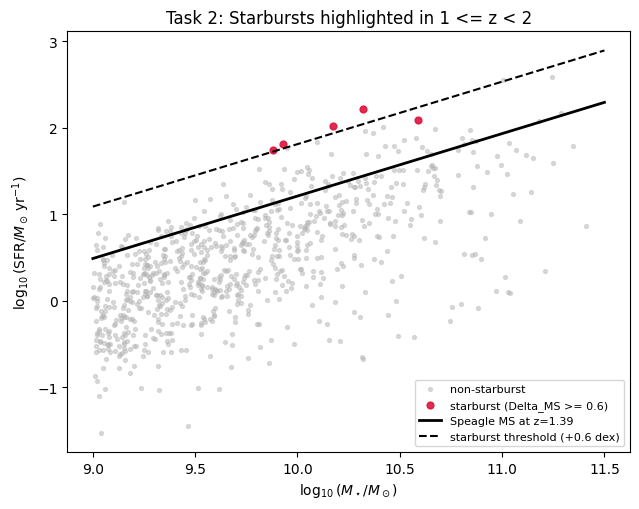

In [16]:
# Visualize starbursts in the chosen redshift bin
plt.figure(figsize=(6.5, 5.2))

plt.scatter(
    log10M_selected[non_starburst_mask],
    log10SFR_selected[non_starburst_mask],
    s=8,
    color='0.7',
    alpha=0.45,
    label='non-starburst'
)

plt.scatter(
    log10M_selected[starburst_mask],
    log10SFR_selected[starburst_mask],
    s=24,
    color='crimson',
    alpha=0.9,
    label='starburst (Delta_MS >= 0.6)'
)

z_med = float(np.median(z_selected[zbin_mask])) if np.any(zbin_mask) else 1.5
x_grid = np.linspace(9.0, 11.5, 200)
y_ms = speagle_log10sfr(x_grid, np.full_like(x_grid, z_med))

plt.plot(x_grid, y_ms, color='black', lw=2, label=f'Speagle MS at z={z_med:.2f}')
plt.plot(x_grid, y_ms + 0.6, color='black', lw=1.5, ls='--', label='starburst threshold (+0.6 dex)')

plt.xlabel(r'$\log_{10}(M_\star/M_\odot)$')
plt.ylabel(r'$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$')
plt.title('Task 2: Starbursts highlighted in 1 <= z < 2')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


Gray - normal galaixes in that redshift bin

Red - Galaxies classified as starbursts (>=0.6dex)

Black line - Expected main-seq line from speagle at 
z = 1.39 (median redshift for galaxies in this bin)




Instead of the first bin, trying 1.5-2.5. so around z~2.

Cutoff for high mass galaxies 10^10 solar masses b/c this is closer to what was being looked at in the papers.

Counted galaxies in this slice for fraction of starburst.

In [16]:
# Optional: literature-style z~2 check (1.5 <= z < 2.5, M >= 10)
z2_mask = (
    sf_ms_mask
    & (z_selected >= 1.5)
    & (z_selected < 2.5)
    & (log10M_selected >= 10.0)
)
z2_starburst = z2_mask & (delta_ms >= 0.6)

n_z2 = int(np.sum(z2_mask))
n_z2_sb = int(np.sum(z2_starburst))
frac_z2 = n_z2_sb / n_z2 if n_z2 > 0 else np.nan

sfr_z2_total = np.sum(10 ** log10SFR_selected[z2_mask])
sfr_z2_sb = np.sum(10 ** log10SFR_selected[z2_starburst])
frac_z2_sfr = sfr_z2_sb / sfr_z2_total if sfr_z2_total > 0 else np.nan

print('z~2 check (1.5 <= z < 2.5, M >= 10):')
print(f'N = {n_z2}, N(starburst) = {n_z2_sb}, number fraction = {frac_z2:.3%}')
print(f'SFR share from starbursts = {frac_z2_sfr:.3%}')


z~2 check (1.5 <= z < 2.5, M >= 10):
N = 126, N(starburst) = 2, number fraction = 1.587%
SFR share from starbursts = 26.862%


#### Task 2 rerun with larger sample size

To improve tail statistics (few starbursts at 10k), we regenerate larger mock catalogs and recompute starburst fractions using the same definition (`Delta_MS >= 0.6 dex`).


In [17]:
import time

def starburst_summary_from_mock(n_samples, seed=7):
    np.random.seed(seed)
    torch.manual_seed(seed)

    base_noise, base_sigma, base_phi = catalogue_generator.generate_base_samples(n_samples)
    noisy_fluxes, noisy_magnitudes, noisy_asinh_magnitudes, flux_sigmas, theta_samples, model_fluxes = catalogue_generator(base_noise, base_sigma, base_phi)

    lims = torch.inf * torch.ones(26)
    lims[-2] = 26.0
    selection = catalogue_generator.selection_cut(noisy_fluxes, noisy_magnitudes, flux_sigmas, lims).detach().numpy()

    log10M_formed, _, log10SFR, log10sSFR = compute_derived_quantities(theta_samples, return_bins=False)
    log10M_remain, log10sSFR, _ = compute_mass_remaining(
        log10M_formed,
        log10sSFR,
        theta_samples,
        mass_theta_shift,
        mass_theta_scale,
        mass_remaining_emulator,
    )

    z = theta_samples.detach().numpy()[selection, -1]
    log10M = log10M_remain.detach().numpy()[selection]
    log10SFR = log10SFR.detach().numpy()[selection]
    log10sSFR = log10sSFR.detach().numpy()[selection]

    finite = (
        np.isfinite(log10M)
        & np.isfinite(log10SFR)
        & np.isfinite(log10sSFR)
        & np.isfinite(z)
    )
    sf_ms = (
        finite
        & (z >= 0.0)
        & (z < 4.0)
        & (log10M >= 8.5)
        & (log10M <= 11.5)
        & (log10sSFR > -11.0)
    )

    delta_ms_local = log10SFR - speagle_log10sfr(log10M, z)

    # Main Task 2 bin
    zbin = sf_ms & (z >= 1.0) & (z < 2.0) & (log10M >= 9.0) & (log10M <= 11.5)
    sb = zbin & (delta_ms_local >= 0.6)

    n_total = int(np.sum(zbin))
    n_sb = int(np.sum(sb))
    frac_num = (n_sb / n_total) if n_total > 0 else np.nan

    sfr_total = np.sum(10 ** log10SFR[zbin])
    sfr_sb = np.sum(10 ** log10SFR[sb])
    frac_sfr = (sfr_sb / sfr_total) if sfr_total > 0 else np.nan

    # High-mass subset (z~2 literature-style)
    z2_hm = sf_ms & (z >= 1.5) & (z < 2.5) & (log10M >= 10.0)
    z2_hm_sb = z2_hm & (delta_ms_local >= 0.6)

    n_z2 = int(np.sum(z2_hm))
    n_z2_sb = int(np.sum(z2_hm_sb))
    frac_z2 = (n_z2_sb / n_z2) if n_z2 > 0 else np.nan

    sfr_z2 = np.sum(10 ** log10SFR[z2_hm])
    sfr_z2_sb = np.sum(10 ** log10SFR[z2_hm_sb])
    frac_z2_sfr = (sfr_z2_sb / sfr_z2) if sfr_z2 > 0 else np.nan

    return {
        'n_samples': int(n_samples),
        'n_task2_total': n_total,
        'n_task2_starburst': n_sb,
        'task2_frac_num': float(frac_num),
        'task2_frac_sfr': float(frac_sfr),
        'n_z2_hm_total': n_z2,
        'n_z2_hm_starburst': n_z2_sb,
        'z2_hm_frac_num': float(frac_z2),
        'z2_hm_frac_sfr': float(frac_z2_sfr),
    }

sample_sizes = [10_000, 50_000, 100_000]
results_largeN = []

for n in sample_sizes:
    t0 = time.time()
    r = starburst_summary_from_mock(n_samples=n, seed=7)
    r['runtime_sec'] = float(time.time() - t0)
    results_largeN.append(r)

print('Task 2 larger-sample rerun (same cuts/definition):')
print('n_samples | N(1<=z<2) | N_SB | frac_SB(%) | SB_SFR_share(%) | N(z~2, M>=10) | N_SB | frac_SB(%) | SB_SFR_share(%) | runtime(s)')
for r in results_largeN:
    print(
        f"{r['n_samples']:>8d} | {r['n_task2_total']:>9d} | {r['n_task2_starburst']:>4d} | "
        f"{100*r['task2_frac_num']:>10.3f} | {100*r['task2_frac_sfr']:>14.3f} | "
        f"{r['n_z2_hm_total']:>13d} | {r['n_z2_hm_starburst']:>4d} | "
        f"{100*r['z2_hm_frac_num']:>10.3f} | {100*r['z2_hm_frac_sfr']:>14.3f} | {r['runtime_sec']:.1f}"
    )


Task 2 larger-sample rerun (same cuts/definition):
n_samples | N(1<=z<2) | N_SB | frac_SB(%) | SB_SFR_share(%) | N(z~2, M>=10) | N_SB | frac_SB(%) | SB_SFR_share(%) | runtime(s)
   10000 |       791 |    5 |      0.632 |          6.710 |           126 |    2 |      1.587 |         26.862 | 52.8
   50000 |      3844 |   12 |      0.312 |          6.041 |           632 |    4 |      0.633 |         13.829 | 289.5
  100000 |      7686 |   20 |      0.260 |          7.280 |          1303 |    9 |      0.691 |         12.821 | 710.7


### Task 3 — What exactly is “SFR” in each source?

---

#### **pop-cosmos (Alsing+2024; Thorp+2025, App. C)**

- SFH is piecewise‑constant in 7 time bins.  
- First two bins are fixed at **0–30 Myr** and **30–100 Myr**.  
- The fitted SFH parameters are the **SFR ratios between adjacent bins**,  
  written as  
  $$\Delta \log_{10}(\mathrm{SFR})_k.$$
- SFR is defined as the **average over the most recent 100 Myr**:

  $$
  \frac{\mathrm{SFR}}{M_{\mathrm{form}}}
  = \frac{M_{\mathrm{form},1}/M_{\mathrm{form}} + M_{\mathrm{form},2}/M_{\mathrm{form}}}{0.1\ \mathrm{Gyr}}
  $$

- In this notebook, `log10SFR_selected` is this **100 Myr–averaged absolute SFR** (in Msun/yr Solar masses/year)
- `log10sSFR_selected` is corrected to use **remaining mass** $(M_{\mathrm{remain}})$ rather than mass formed.

---

#### **Speagle et al. (2014)**

- Gives this relation for SFR galaxies

$$
\log_{10}\mathrm{SFR}(M_\ast, t)
= (0.84 - 0.026 t)\,\log_{10} M_\ast
  - (6.51 - 0.11 t)
$$


  where \(t\) is cosmic time in Gyr.

- Didn't measure one single galaxy with one single pipeline, collected many published studies (25) and converted them into a common scale and then fit one global formula for the main seq across cosmic time.
- Intrinsic MS width was ~0.2 dex
- Galaxies scatter around the MS line, Speagle SFR is a calibrated avg across many works.

---

#### **COSMOS2020 catalog (Weaver+2022)**
  COSMOS2020 gives galaxies properties from photometric SEC fitting. The two main pipelines are:
- **LePhare outputs:**  
  `lp_SFR_med`, `lp_SFR_best` BC03 templates
- **EAZY/FSPS outputs:**  
  `ez_sfr` FSPS based output

  Take observed fluxes in many filters, compare to model templates and then infer redshift and physical params like SFR, mass etc.

  They don't account for IR, so could not be accounting for Dust. So SFR could be underestimated.
---


## Magnitude distributions

Now we can plot the broadband magnitudes of the selected mock galaxy population. This will give us something a bit like Figure 1 in Thorp et al. (2025).

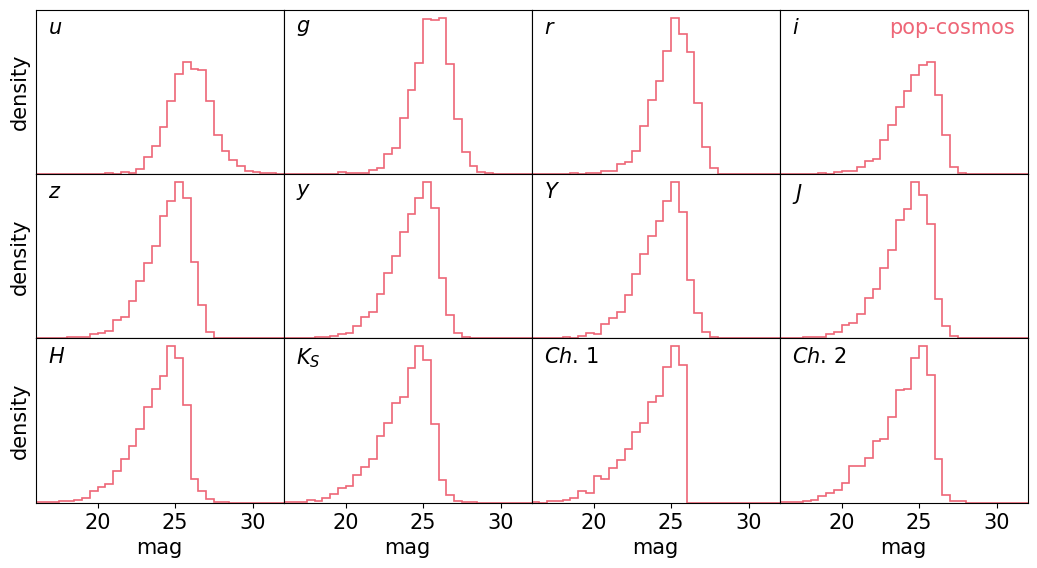

In [9]:
#Plot the broadband magnitudes(logarithmic) as predicted by the pop-cosmos model
plt.rcParams.update({"font.size": 15})
mag_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, -2, -1]

x_bins = np.linspace(16, 32, 33)
hist_color = "#EE6677"
figsize = (12.8, 6.4)
xlim = (16, 32)
xticks = [20, 25, 30]

fig, axes = plt.subplots(3, 4, figsize=figsize)
axes = axes.flatten()

# Loop through all channels for a histogram plot
for i, mag_idx in enumerate(mag_list):
    ax = axes[i]
    
    ax.hist(noisy_magnitudes_selected[:, mag_idx], 
            color=hist_color, bins=x_bins, histtype="step", 
            linewidth=1.2, density=True)
    
    # Filter labels
    ax.text(0.05, 0.95, COSMOS_FILTERS_LATEX[mag_idx], 
            transform=ax.transAxes, verticalalignment='top')
    
    if i == 3:
        ax.text(0.95, 0.95, "pop-cosmos", transform=ax.transAxes, 
                verticalalignment='top', horizontalalignment="right", 
                color=hist_color)
    
    if i in [0, 3]: 
        ax.set_ylim(0, ax.get_ylim()[1] * 1.4)

    if i % 4 == 0: 
        ax.set_ylabel('density')
    ax.set_yticks([])
    
    ax.set_xlim(xlim)
    if i > 7: 
        ax.set_xlabel('mag')
        ax.set_xticks(xticks)
    else:
        ax.set_xticks([])

plt.subplots_adjust(hspace=0, wspace=0)
plt.show()

## Colour distributions

Now we can plot the broadband colours of the selected mock galaxy population. This will give us something a bit like Figure 2 in Thorp et al. (2025).

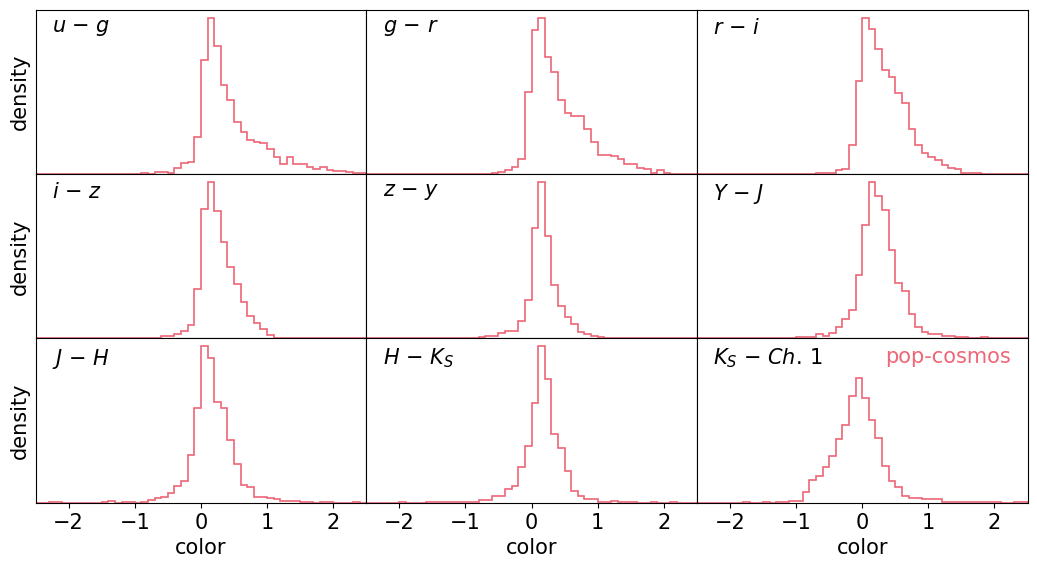

In [9]:
# Plot the broadband colors (logarithmic, adjacent bands) as predicted by the pop-cosmos model
mag_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, -2]
x_bins = np.linspace(-2.5, 2.5, 51)
hist_color = "#EE6677"
figsize = (12.8, 6.4)
xlim = (-2.5, 2.5)
xticks = [-2, -1, 0, 1, 2]

# Create color pairs
color_pairs = [(mag_list[i], mag_list[i+1]) 
               for i in range(len(mag_list)-1) 
               if i != 5]


fig, axes = plt.subplots(3, 3, figsize=figsize)
axes = axes.flatten()

# Loop through all color pairs to create a histogram plot
for plot_idx, (mag1, mag2) in enumerate(color_pairs):
    ax = axes[plot_idx]
    
    # Calculate color difference
    color_diff = noisy_magnitudes_selected[:, mag1] - noisy_magnitudes_selected[:, mag2]
    

    ax.hist(color_diff, color=hist_color, bins=x_bins, 
            histtype="step", linewidth=1.2, density=True)
    

    color_label = f"{COSMOS_FILTERS_LATEX[mag1]} $-$ {COSMOS_FILTERS_LATEX[mag2]}"
    ax.text(0.05, 0.95, color_label, transform=ax.transAxes, 
            verticalalignment='top')
    
 
    if plot_idx == 8:
        ax.text(0.95, 0.95, "pop-cosmos", transform=ax.transAxes, 
                verticalalignment='top', horizontalalignment="right", 
                color=hist_color)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.25)
    

    if plot_idx % 3 == 0:  
        ax.set_ylabel('density')
    ax.set_yticks([])
    

    ax.set_xlim(xlim)
    if plot_idx >= 6: 
        ax.set_xlabel('color')
        ax.set_xticks(xticks)
    else:
        ax.set_xticks([])


plt.subplots_adjust(hspace=0, wspace=0)
plt.show()

## Plot the $n(z)$

Now, we'll plot the redshift distribution of the mock galaxy catalog.

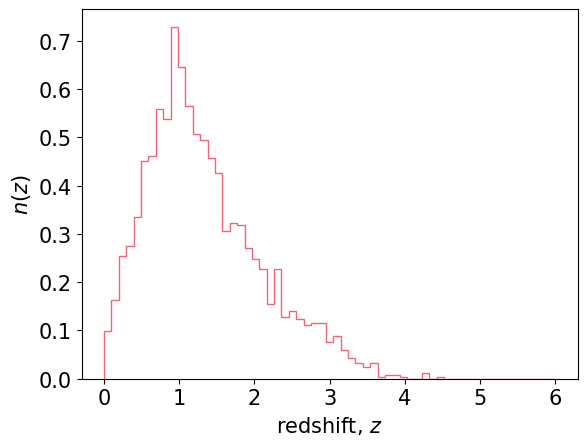

In [10]:
#Plot the reshift distribution predicted by the pop-cosmos model
plt.hist(thetas_selected[:,-1], bins=61, color="#EE6677", histtype="step", density=True, range=(0,6))
plt.xlabel("redshift, $z$")
plt.ylabel("$n(z)$")
plt.show()

## Plot the $n(M)$

Now, we'll plot the mass distribution of the mock galaxy catalog.

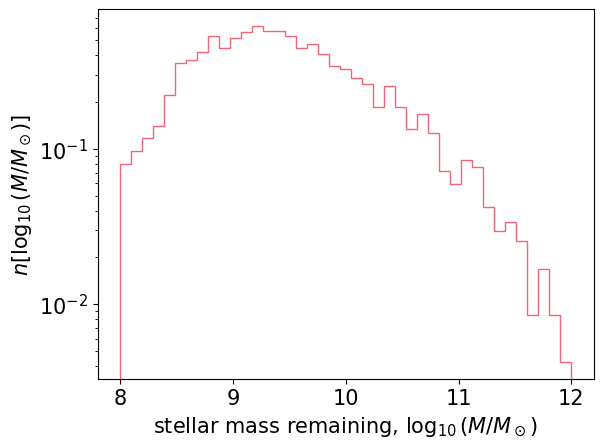

In [11]:
#Plot the stellar mass function predicted by the pop-cosmos model
plt.hist(log10M_selected, bins=41, color="#EE6677", histtype="step", density=True, range=(8,12))
plt.xlabel("stellar mass remaining, $\\log_{10}(M/M_\\odot)$")
plt.ylabel("$n[\\log_{10}(M/M_\\odot)]$")
plt.yscale("log")
plt.show()

## Plot some star formation histories

Now, we'll try to plot some model star formation histories in the style of Deger et al. (2025).

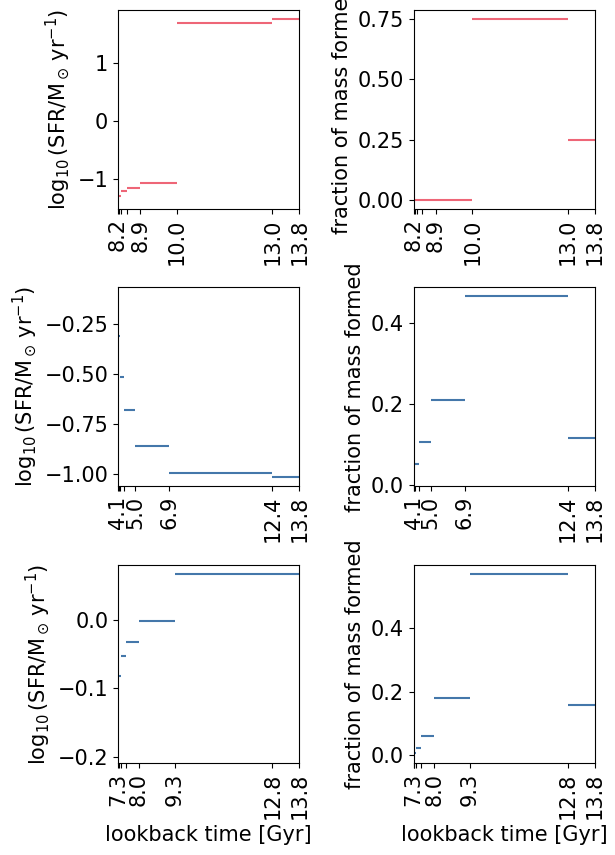

In [12]:
#Choose three random model galaxies and plot their SFH
idx = np.random.choice(len(log10SFH_selected), 3, replace=False)
fig, axes = plt.subplots(3, 2, figsize=(6.4, 8.8), sharex='row')

for j, i in enumerate(idx):
    t_edge = t_edge_selected[i] + Planck18.lookback_time(thetas_selected[i,-1]).value
    t_width = t_edge_selected[i,1:] - t_edge_selected[i,:-1]
    #Red if Q, blue if SF
    color = '#EE6677' if log10sSFR_selected[i] < -11 else '#4477AA'
    #We'll use a horizontal errorbar as a quick way to plot the piecewise constant functions
    axes[j,0].errorbar(t_edge[:-1], log10SFH_selected[i], xerr=[np.zeros_like(t_width), t_width], linestyle='', color=color)
    axes[j,1].errorbar(t_edge[:-1], M_frac_selected[i], xerr=[np.zeros_like(t_width), t_width], linestyle='', color=color)
    axes[j,0].set_xlim(t_edge[0], t_edge[-1])
    axes[j,0].set_ylabel('$\\log_{10}(\\mathrm{SFR}/\\mathrm{M}_\\odot\\,\\mathrm{yr}^{-1}$)')
    axes[j,1].set_ylabel('fraction of mass formed')
    axes[j,0].set_xticks(t_edge, [np.round(t_edge[0],1)] + ['']*3 + list(np.round(t_edge[-4:],1)), rotation=90)
    axes[j,1].set_xticks(t_edge, [np.round(t_edge[0],1)] + ['']*3 + list(np.round(t_edge[-4:],1)), rotation=90)
axes[-1,0].set_xlabel('lookback time [Gyr]')
axes[-1,1].set_xlabel('lookback time [Gyr]')
plt.tight_layout()
plt.show()

## Generate magnitudes for a different survey

Now, we can load in some different photometry emulators, and can generate some model magnitudes in those bands. We'll only be able to generate model fluxes or magnitudes (for now), as we don't have a noise model. We can try generating magnitudes for the Vera Rubin Observatory's and Roman Space Telescope's filters, using the emulators from `trained_models/photulator_models`. 

We can also add emission line strength corrections using the models from `trained_models/emline_bandpass_models` and `trained_models/emline_speculator_models`.

In [13]:
#Load in a Photulator model stack for the Rubin/LSST filters
from speculator import PhotulatorModelStack
emulator_path = '../trained_models/photulator_models/LSST/'
emulator_name = 'model_4x128_alsing20_lsst_baseline_1_9_{}_cpu.pt'
rubin_filter_names = 'ugrizy'
rubin_filter_colors = ["#0c71ff", "#49be61", "#c61c00", "#ffc200", "#f341a2", "#5d0000"]
rubin_flux_emulator = PhotulatorModelStack('', [emulator_path + emulator_name.format(f) 
                                                for f in rubin_filter_names])

#Load in a Photulator model stack for the Roman/WFI filters
from speculator import PhotulatorModelStack
emulator_path = '../trained_models/photulator_models/Roman/'
emulator_name = 'model_4x128_alsing20_roman_wfi_f{}_cpu.pt'
roman_filter_names = ['062', '087', '106', '129', '146', '158', '184', '213']
roman_filter_colors = ["#0011cf", "#8a2be2", "#3cb372", "#ff8d02", "#666666", "#ff4500", "#fe00ff", "#ff0300"]
roman_flux_emulator = PhotulatorModelStack('', [emulator_path + emulator_name.format(f) 
                                                for f in roman_filter_names])

In [14]:
#Build an EmLineEmulator for the Rubin/LSST filters
rubin_emline_flux_emulator = EmLineEmulator('../trained_models/emline_speculator_models/',
                                                   '../trained_models/emline_bandpass_models/LSST/',
                                                   'cpu', 
                                                   ['lsst_baseline_1_9_{}'.format(f) 
                                                    for f in rubin_filter_names],
                                                    n_parameters=16,
                                                    n_hidden=[128, 128, 128])
#Build an EmLineEmulator for the Roman/WFI filters
roman_emline_flux_emulator = EmLineEmulator('../trained_models/emline_speculator_models/',
                                                   '../trained_models/emline_bandpass_models/Roman/',
                                                   'cpu', 
                                                   ['roman_wfi_f{}'.format(f) 
                                                    for f in roman_filter_names],
                                                    n_parameters=16,
                                                    n_hidden=[128, 128, 128])

We can generate Rubin and Roman magnitudes by passing the SPS parameters from our mock catalog through the emulator model stack. The calling signature for the `magnitudes` method of the `PhotulatorModelStack` will need us to use a parameter transform that we can get from the `CatalogueGenerator` we loaded in earlier.

In [15]:
#Transform the base SPS parameters into the format the emulators need
thetas_transformed = catalogue_generator.emulator_parameter_transform(torch.from_numpy(thetas_selected))
# We have to seperate the first column as a second argument to the emulator
rubin_magnitudes = rubin_flux_emulator.magnitudes(thetas_transformed[:,1:], thetas_transformed[:,0].unsqueeze(-1))
rubin_magnitudes = rubin_magnitudes.detach().cpu().numpy()
# Same calculation for Roman bands
roman_magnitudes = roman_flux_emulator.magnitudes(thetas_transformed[:,1:], thetas_transformed[:,0].unsqueeze(-1))
roman_magnitudes = roman_magnitudes.detach().cpu().numpy()

The `EmLineEmulator` will expect the same transformed parameter tensor as the `PhotulatorModelStack`.

In [16]:
#Optionally compute emission line strength corrections
rubin_emline_flux_contributions = rubin_emline_flux_emulator(thetas_transformed)
roman_emline_flux_contributions = roman_emline_flux_emulator(thetas_transformed)
#Print the shape of the emission line flux tensor
print(rubin_emline_flux_contributions.shape)

torch.Size([2551, 6, 44])


The emission line fluxes will have shape (6,44) for each galaxy, containing the flux contributions of 44 emission lines to each of the 6 Rubin/LSST bands. Similarly, the tensor of Roman emission line fluxes will have shape (8,44) per galaxy, corresponding to the same 44 lines, but 8 Roman/WFI bands.

We can use the same fractional emission line strength corrections as we used for COSMOS, as these are per-line corrections, rather than per-band. We can multiply our emission line fluxes by these fractional corrections, then sum over the lines to compute the net flux offset per band.

In [17]:
rubin_emline_flux_offsets = torch.sum(catalogue_generator.emline_offsets * rubin_emline_flux_contributions, dim=-1).detach().cpu().numpy() # flux offsets in nanomaggies
rubin_fluxes = 10**(0.4*(22.5 - rubin_magnitudes)) + rubin_emline_flux_offsets
rubin_magnitudes = 22.5 - 2.5*np.log10(rubin_fluxes)

roman_emline_flux_offsets = torch.sum(catalogue_generator.emline_offsets * roman_emline_flux_contributions, dim=-1).detach().cpu().numpy() # flux offsets in nanomaggies
roman_fluxes = 10**(0.4*(22.5 - roman_magnitudes)) + roman_emline_flux_offsets
roman_magnitudes = 22.5 - 2.5*np.log10(roman_fluxes)

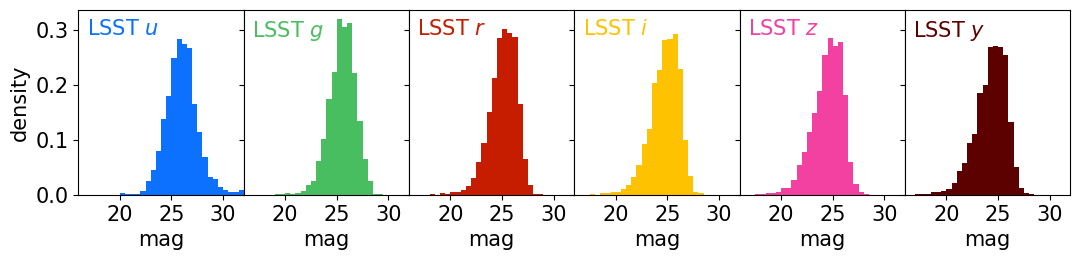

In [18]:
#Plot the broadband magnitudes(logarithmic) as predicted by the pop-cosmos model for Rubin
plt.rcParams.update({"font.size": 15})

x_bins = np.linspace(16, 32, 33)
figsize = (12.8, 2.4)
xlim = (16, 32)
xticks = [20, 25, 30]

fig, axes = plt.subplots(1, 6, figsize=figsize, sharey='row')

# Loop through all channels for a histogram plot
for idx in range(len(rubin_filter_names)):
    ax = axes[idx]
    ax.hist(rubin_magnitudes[:, idx], 
            color=rubin_filter_colors[idx], bins=x_bins, 
            linewidth=1.2, density=True)
    
    # Filter labels
    ax.text(0.05, 0.95, 'LSST ${}$'.format(rubin_filter_names[idx]), 
            color=rubin_filter_colors[idx], transform=ax.transAxes, verticalalignment='top')

    if idx == 0: 
        ax.set_ylabel('density')
    ax.set_xlim(xlim)
    ax.set_xlabel('mag')
    ax.set_xticks(xticks)
plt.subplots_adjust(hspace=0, wspace=0)
plt.show()

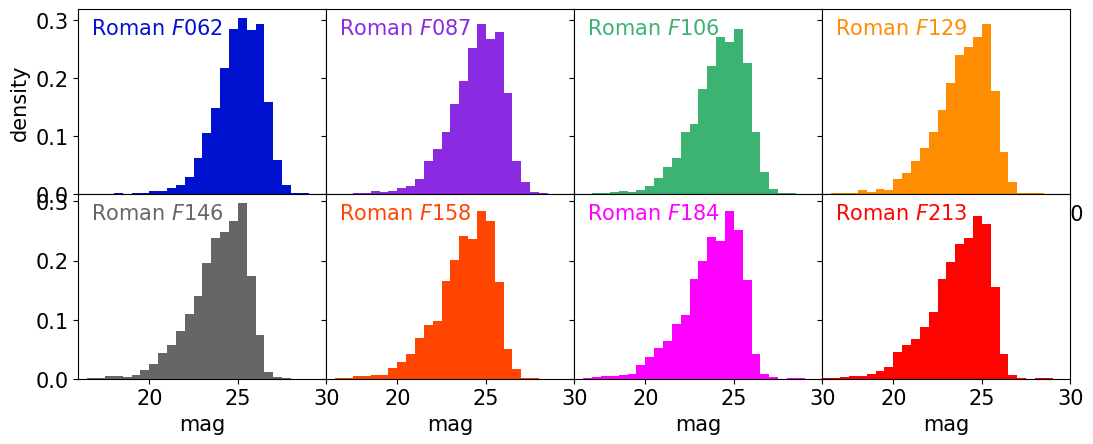

In [19]:
#Plot the broadband magnitudes(logarithmic) as predicted by the pop-cosmos model for Roman
plt.rcParams.update({"font.size": 15})

x_bins = np.linspace(16, 32, 33)
figsize = (12.8, 4.8)
xlim = (16, 30)
xticks = [20, 25, 30]

fig, axes = plt.subplots(2, 4, figsize=figsize, sharey='row')
axes = axes.flatten()

# Loop through all channels for a histogram plot
for idx in range(len(roman_filter_names)):
    ax = axes[idx]
    ax.hist(roman_magnitudes[:, idx], 
            color=roman_filter_colors[idx], bins=x_bins, 
            linewidth=1.2, density=True)
    
    # Filter labels
    ax.text(0.05, 0.95, 'Roman $F{}$'.format(roman_filter_names[idx]), 
            color=roman_filter_colors[idx], transform=ax.transAxes, verticalalignment='top')

    if idx == 0: 
        ax.set_ylabel('density')
    ax.set_xlim(xlim)
    ax.set_xlabel('mag')
    ax.set_xticks(xticks)
plt.subplots_adjust(hspace=0, wspace=0)
plt.show()